# Progetto della parte finale del corso di "Data Mining" da 12 CFU

## MODULE 1: Imbalanced Learning

* Define one simple unbalanced classification tasks and solve it either with a
  Decision Tree or KNN.
* If the dataset is already unbalanced, leave it as it is; otherwise, modify it to
  create an imbalanced version (e.g., 96% - 4%, for binary classification).
* Solve the classification task using the Decision Tree or KNN by adopting at
  least 2 techniques of imbalanced learning (Undersampling, Oversampling).
  * for Undersampling -> RANDOM UNDERSAMPLING
  * for Oversampling -> SMOTE
* Analyse and discuss the impact of these techniques, focusing on class
  distribution and detailed performance metrics.

---

### Informazioni Generali

* **Corso:** Data Mining
* **Università:** Università di Pisa
* **Anno Accademico:** 2024/2025

### Autore

* **Studente:** Giuseppe Muschetta
* **Matricola:** 564026

### Dataset Utilizzato

* **Nome:** Extended IMDb Dataset (Tabulare)
* **Descrizione:** Dataset tabulare contenente circa 150,000 record con informazioni relative ai titoli cinematografici.#%% md


In [1]:
import pandas as pd
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns


# --- IMPOSTAZIONI GLOBALI PER I GRAFICI ---
plt.style.use("dark_background")
sns.set_theme(
    style="darkgrid", context="notebook", palette="icefire",
    font="sans-serif", font_scale=1.1
)
plt.rcParams.update({
    'axes.labelweight': 'bold', 'axes.titleweight': 'bold', 'axes.edgecolor': 'white',
    'axes.labelcolor': 'white', 'xtick.color': 'lightgray', 'ytick.color': 'lightgray',
    'text.color': 'white', 'figure.facecolor': '#111111', 'axes.facecolor': '#111111',
    'savefig.facecolor': '#111111'
})
print("✅ Impostazioni grafiche caricate.")

# --- CREAZIONE DIRECTORY PER I PLOT ---
plots_dir = 'plots_imbalanced_learning/'
os.makedirs(plots_dir, exist_ok=True)
print(f"✅ Directory per i grafici '{plots_dir}' pronta.")

# --- CARICAMENTO DEL DATASET PREPARATO ---
dataset_dir = 'dataset/'
dataset_name = 'imdb_prepared_no_outliers.csv'
try:
    data = pd.read_csv(os.path.join(dataset_dir, dataset_name))
    print(f"✅ Dataset preparato caricato: {data.shape[0]} righe, {data.shape[1]} colonne.")
except FileNotFoundError as e:
    print(f"❌ Errore: File non trovato. Assicurati di aver eseguito il Modulo 0 e salvato '{dataset_name}'.")
    exit(1)


✅ Impostazioni grafiche caricate.
✅ Directory per i grafici 'plots_imbalanced_learning/' pronta.
✅ Dataset preparato caricato: 148432 righe, 109 colonne.


In [2]:
data.head()

,originalTitle,rating,startYear,endYear,runtimeMinutes,awardWins,numVotes,totalImages,totalVideos,totalCredits,...,userReviewsTotal_proc,companiesNumber_proc,averageRating_proc,writerCredits_proc,directorsCredits_proc,quotesTotal_proc,winRate_proc,contentRichness_proc,logPopularityScore_proc,criticUserRatio_proc
0,Carmencita,"(5, 6]",1894,\N,1.0,0,2089,2,0,4,...,1.836167,0.168822,-0.919474,-1.33565,0.244167,-0.400731,-0.299870,-1.486015,1.552267,2.102152
1,Un bon bock,"(5, 6]",1892,\N,12.0,0,183,2,0,2,...,0.777289,-1.530391,-1.099138,-1.33565,0.244167,-0.400731,-0.299870,-1.611139,1.082526,-0.465842
2,Chinese Opium Den,"(4, 5]",1894,\N,1.0,0,195,1,0,1,...,-0.737922,-0.766296,-1.328129,-1.33565,0.244167,-0.400731,-0.299870,-1.740513,-0.863379,-0.465842
3,Edison Kinetoscopic Record of a Sneeze,"(5, 6]",1894,\N,1.0,1,2237,3,0,4,...,1.855327,0.821188,-1.099138,-1.33565,0.244167,-0.400731,3.347882,-1.425032,1.562992,1.995890
4,L'arrivée d'un train à La Ciotat,"(7, 8]",1896,\N,1.0,0,13115,12,0,11,...,1.904733,0.654420,0.296101,-1.33565,1.435843,-0.400731,-0.299870,-0.587026,1.683882,2.160761


In [3]:
data.info(verbose=True, show_counts=True, memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148432 entries, 0 to 148431
Data columns (total 109 columns):
 #    Column                            Non-Null Count   Dtype  
---   ------                            --------------   -----  
 0    originalTitle                     148432 non-null  object 
 1    rating                            148432 non-null  object 
 2    startYear                         148432 non-null  int64  
 3    endYear                           148432 non-null  object 
 4    runtimeMinutes                    148432 non-null  float64
 5    awardWins                         148432 non-null  int64  
 6    numVotes                          148432 non-null  int64  
 7    totalImages                       148432 non-null  int64  
 8    totalVideos                       148432 non-null  int64  
 9    totalCredits                      148432 non-null  int64  
 10   criticReviewsTotal                148432 non-null  int64  
 11   awardNominationsExcludeWins       148

#### Scelta della variabile target

In [4]:
# Create the New Target Column 'isDocumentary'
if 'genres_documentary' in data.columns:
    # Create a new 'isDocumentary' column as a copy to use as the target
    data['isDocumentary'] = data['genres_documentary']
    print("✅ Target column 'isDocumentary' created as a copy of 'genres_documentary'.")
else:
    print("❌ Attention: The 'genres_documentary' column was not found in the dataset.")
    exit(1)


# Analisi della Distribuzione di Classe
print("\n--- Analisi della Distribuzione della Variabile Target 'isDocumentary' ---")
class_distribution = data['isDocumentary'].value_counts(normalize=True) * 100

print(f"Distribuzione delle classi:")
print(f"  - Non-Documentari (0): {class_distribution[0]:.2f}%")
print(f"  - Documentari (1):     {class_distribution[1]:.2f}%")

if class_distribution[1] < 20:
    print("\nConferma: Il dataset è naturalmente sbilanciato. Ottimo per il nostro task!")
else:
    print("\nIl dataset è abbastanza bilanciato. Potremmo dover creare uno sbilanciamento artificiale.")


✅ Target column 'isDocumentary' created as a copy of 'genres_documentary'.

--- Analisi della Distribuzione della Variabile Target 'isDocumentary' ---
Distribuzione delle classi:
  - Non-Documentari (0): 88.87%
  - Documentari (1):     11.13%

Conferma: Il dataset è naturalmente sbilanciato. Ottimo per il nostro task!


#### Creazione del dataset sbilanciato 96% e 4%

In [5]:
import pandas as pd
from sklearn.utils import shuffle

# --- 1. Separazione delle Classi ---
majority_df = data[data['isDocumentary'] == 0]
minority_df = data[data['isDocumentary'] == 1]

print(f"Dimensione originale - Classe Maggioritaria (Non-Documentari): {len(majority_df)} righe")
print(f"Dimensione originale - Classe Minoritaria (Documentari):     {len(minority_df)} righe")

# --- 2. Calcolo delle Dimensioni per il Rapporto 96/4 ---
target_ratio = 96 / 4
n_minority_final = int(len(majority_df) / target_ratio)
n_majority_final = int(n_minority_final * target_ratio)

print(f"\nPer ottenere un rapporto 96/4, campioneremo:")
print(f"  - {n_majority_final} campioni dalla classe maggioritaria.")
print(f"  - {n_minority_final} campioni dalla classe minoritaria.")

# --- 3. Campionamento ---
majority_sampled = majority_df.sample(n=n_majority_final, random_state=42)
minority_sampled = minority_df.sample(n=n_minority_final, random_state=42)

# --- 4. Unione, Reset dell'Indice e Shuffle ---
# Uniamo i due campioni e usiamo ignore_index=True per creare un nuovo indice pulito
data_imbalanced = pd.concat([majority_sampled, minority_sampled], ignore_index=True)

# Mescoliamo il dataset per distribuire casualmente le classi
data_imbalanced = shuffle(data_imbalanced, random_state=42)

# --- 5. Verifica Finale ---
print(f"\n--- Verifica del Nuovo Dataset Sbilanciato ---")
print(f"Shape del nuovo dataset: {data_imbalanced.shape}")

final_distribution = data_imbalanced['isDocumentary'].value_counts(normalize=True) * 100
print(f"\nDistribuzione finale delle classi:")
print(f"  - Non-Documentari (0): {final_distribution[0]:.2f}%")
print(f"  - Documentari (1):     {final_distribution[1]:.2f}%")

if abs(final_distribution[0] - 96) < 0.1 and abs(final_distribution[1] - 4) < 0.1:
    print("\n✅ Successo! Il dataset è stato ricampionato, indicizzato e mescolato correttamente.")
else:
    print("\n❌ Attenzione: Qualcosa è andato storto nel ricampionamento.")

Dimensione originale - Classe Maggioritaria (Non-Documentari): 131909 righe
Dimensione originale - Classe Minoritaria (Documentari):     16523 righe

Per ottenere un rapporto 96/4, campioneremo:
  - 131904 campioni dalla classe maggioritaria.
  - 5496 campioni dalla classe minoritaria.

--- Verifica del Nuovo Dataset Sbilanciato ---
Shape del nuovo dataset: (137400, 110)

Distribuzione finale delle classi:
  - Non-Documentari (0): 96.00%
  - Documentari (1):     4.00%

✅ Successo! Il dataset è stato ricampionato, indicizzato e mescolato correttamente.


#### Preparazione Feature e Suddivisione Train-Test

In [6]:
from sklearn.model_selection import train_test_split

# --- 1. Separation of Features (X) and Target (y) ---

# We select all features that have been processed or one-hot encoded
# based on patterns in their names.
feature_columns = [
    col for col in data_imbalanced.columns
    if '_proc' in col or
       'type_' in col or
       'genres_' in col or
       'countryOfOrigin_' in col or
       'regions_' in col or
       'soundMixes_' in col
]

# Manual addition of the binary feature as requested.
if 'hasWriterAndDirector' not in feature_columns:
    feature_columns.append('hasWriterAndDirector')

# We must exclude the target itself and its direct source to prevent data leakage.
if 'genres_documentary' in feature_columns:
    feature_columns.remove('genres_documentary')

X = data_imbalanced[feature_columns]
y = data_imbalanced['isDocumentary']

print(f"✅ Data separated: {X.shape[1]} features (X) and 1 target variable (y).")


# --- 2. Stratified Split into Training and Test Sets ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("\n--- Train-Test Split Complete ---")
print(f"Training Set Dimensions:  X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test Set Dimensions:      X_test={X_test.shape}, y_test={y_test.shape}")


# --- 3. Verification of Post-Split Distribution ---
train_dist = y_train.value_counts(normalize=True) * 100
test_dist = y_test.value_counts(normalize=True) * 100

print("\nClass distribution in Training Set:")
print(f"  - Non-Documentaries (0): {train_dist[0]:.2f}%")
print(f"  - Documentaries (1):     {train_dist[1]:.2f}%")

print("\nClass distribution in Test Set:")
print(f"  - Non-Documentaries (0): {test_dist[0]:.2f}%")
print(f"  - Documentaries (1):     {test_dist[1]:.2f}%")

✅ Data separated: 85 features (X) and 1 target variable (y).

--- Train-Test Split Complete ---
Training Set Dimensions:  X_train=(96180, 85), y_train=(96180,)
Test Set Dimensions:      X_test=(41220, 85), y_test=(41220,)

Class distribution in Training Set:
  - Non-Documentaries (0): 96.00%
  - Documentaries (1):     4.00%

Class distribution in Test Set:
  - Non-Documentaries (0): 96.00%
  - Documentaries (1):     4.00%


In [7]:
feature_columns

['type_movie',
 'type_short',
 'type_tvEpisode',
 'type_tvMiniSeries',
 'type_tvMovie',
 'type_tvSeries',
 'type_tvShort',
 'type_tvSpecial',
 'type_video',
 'type_videoGame',
 'genres_drama',
 'genres_comedy',
 'genres_action',
 'genres_animation',
 'genres_adventure',
 'genres_short',
 'genres_crime',
 'genres_family',
 'genres_romance',
 'genres_mystery',
 'genres_fantasy',
 'genres_horror',
 'genres_reality-tv',
 'genres_thriller',
 'genres_music',
 'genres_history',
 'genres_sci-fi',
 'genres_talk-show',
 'genres_game-show',
 'countryOfOrigin_us',
 'countryOfOrigin_gb',
 'countryOfOrigin_jp',
 'countryOfOrigin_fr',
 'countryOfOrigin_ca',
 'countryOfOrigin_in',
 'countryOfOrigin_de',
 'countryOfOrigin_it',
 'countryOfOrigin_es',
 'countryOfOrigin_au',
 'regions_us',
 'regions_gb',
 'regions_fr',
 'regions_jp',
 'regions_de',
 'regions_es',
 'regions_it',
 'regions_in',
 'regions_pt',
 'regions_ca',
 'regions_xww',
 'regions_br',
 'regions_au',
 'regions_pl',
 'regions_ru',
 'region

### BASELINE Decision Tree with default parameters and no tuning

--- Training the Baseline Decision Tree on Imbalanced Data ---
✅ Baseline model trained.

--- Performance of the Baseline Model ---
Classification Report:
                     precision    recall  f1-score   support

Non-Documentary (0)       0.97      0.99      0.98     39571
    Documentary (1)       0.57      0.18      0.27      1649

           accuracy                           0.96     41220
          macro avg       0.77      0.59      0.63     41220
       weighted avg       0.95      0.96      0.95     41220


Visualizing performance metrics...


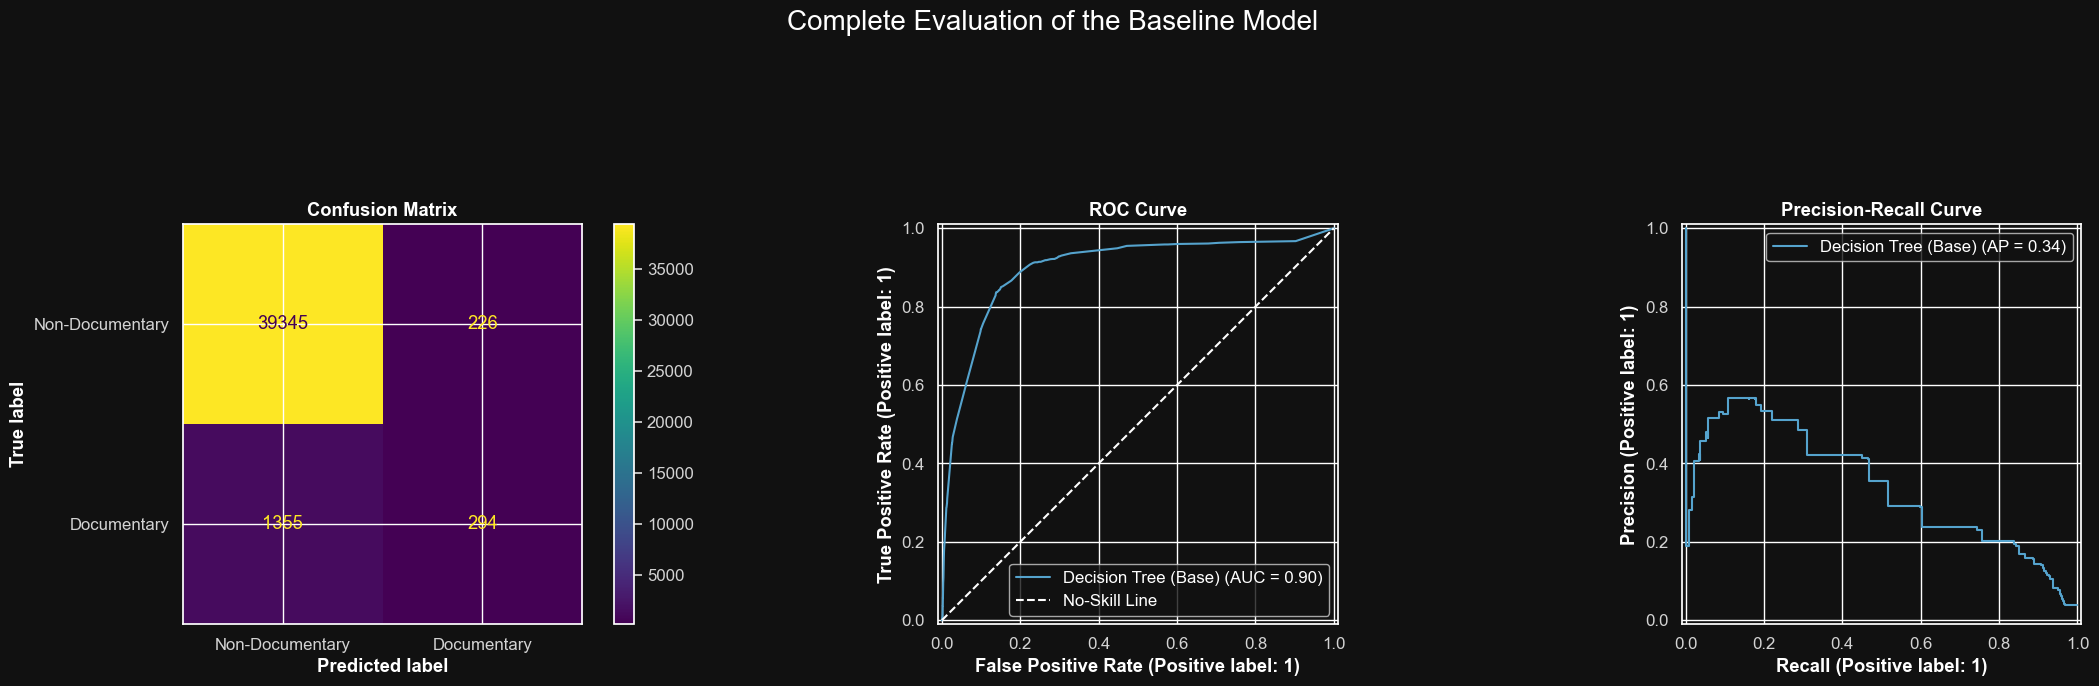


--- Analysis of Feature Importances ---
Top 20 Features with the Highest Importance Score: ['startYear_proc', 'genres_drama', 'writerCredits_proc', 'genres_comedy', 'type_movie', 'genres_history', 'averageRating_proc', 'type_tvMovie', 'genres_action', 'totalCredits_proc', 'genres_reality-tv', 'genres_animation', 'runtimeMinutes_proc', 'type_tvEpisode', 'numVotes_proc', 'numRegions_proc', 'genres_thriller', 'companiesNumber_proc', 'totalImages_proc', 'genres_adventure']


/var/folders/4l/s_d8z1kx7h762hwfcv4xhtsh0000gn/T/ipykernel_4829/3261585627.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_features, y=top_20_features.index, palette='viridis')


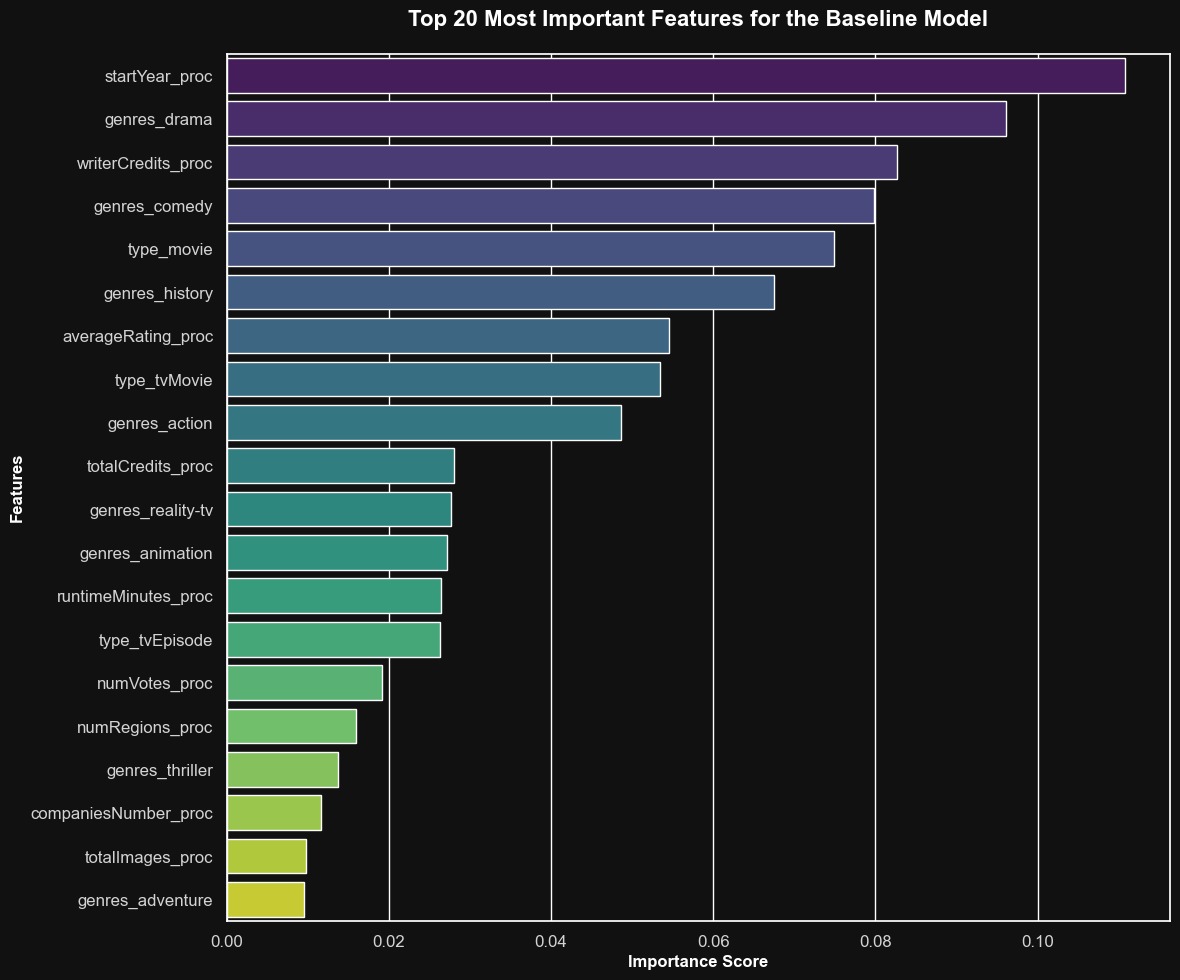

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. Training the Baseline Decision Tree ---
print("--- Training the Baseline Decision Tree on Imbalanced Data ---")
baseline_model = DecisionTreeClassifier(max_depth=10, random_state=42)
baseline_model.fit(X_train, y_train)
print("✅ Baseline model trained.")

# --- 2. Making Predictions on the Test Set ---
y_pred_baseline = baseline_model.predict(X_test)

# --- 3. Evaluating the Baseline Model ---
print("\n--- Performance of the Baseline Model ---")
print("Classification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=['Non-Documentary (0)', 'Documentary (1)']))

# --- 4. Visualizing Performance Metrics ---
print("\nVisualizing performance metrics...")
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle("Complete Evaluation of the Baseline Model", fontsize=20, y=1.03)

# Subplot 1: Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    baseline_model, X_test, y_test,
    ax=axes[0], cmap='viridis', display_labels=['Non-Documentary', 'Documentary']
)
axes[0].set_title("Confusion Matrix", fontweight='bold')

# Subplot 2: ROC Curve
RocCurveDisplay.from_estimator(
    baseline_model, X_test, y_test, ax=axes[1], name='Decision Tree (Base)'
)
axes[1].plot([0, 1], [0, 1], 'w--', label='No-Skill Line')
axes[1].set_title("ROC Curve", fontweight='bold')
axes[1].legend()

# Subplot 3: Precision-Recall Curve
PrecisionRecallDisplay.from_estimator(
    baseline_model, X_test, y_test, ax=axes[2], name='Decision Tree (Base)'
)
axes[2].set_title("Precision-Recall Curve", fontweight='bold')
axes[2].legend()

plt.tight_layout(pad=3.0, rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(plots_dir, "evaluation_charts_baseline.png"), dpi=300)
plt.show()


# --- 5. Feature Importance Analysis ---
print("\n--- Analysis of Feature Importances ---")
# Create a pandas Series with feature importances
feature_importances = pd.Series(baseline_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Select the top 20 features
top_20_features = feature_importances.head(20)

print(f"Top 20 Features with the Highest Importance Score: {top_20_features.index.tolist()}")

# Create the plot
plt.figure(figsize=(12, 10))
sns.barplot(x=top_20_features, y=top_20_features.index, palette='viridis')
plt.title('Top 20 Most Important Features for the Baseline Model', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "feature_importance_baseline.png"), dpi=300)
plt.show()

### SMOTE

--- Applicazione di SMOTE al Training Set ---
✅ SMOTE applicato con successo.

--- Verifica della Distribuzione Post-SMOTE ---
Dimensioni del training set originale: X_train=(96180, 85)
Dimensioni del training set con SMOTE: X_train_smote=(184666, 85)

Distribuzione delle classi nel nuovo training set bilanciato:
isDocumentary
0    92333
1    92333
Name: count, dtype: int64

--- Addestramento del Decision Tree sui dati bilanciati con SMOTE ---
✅ Modello SMOTE addestrato.

--- Performance del Modello SMOTE ---
Classification Report:
                     precision    recall  f1-score   support

Non-Documentary (0)       0.99      0.87      0.93     39571
    Documentary (1)       0.22      0.87      0.36      1649

           accuracy                           0.87     41220
          macro avg       0.61      0.87      0.64     41220
       weighted avg       0.96      0.87      0.91     41220


Visualizzazione delle metriche di performance per il modello SMOTE...


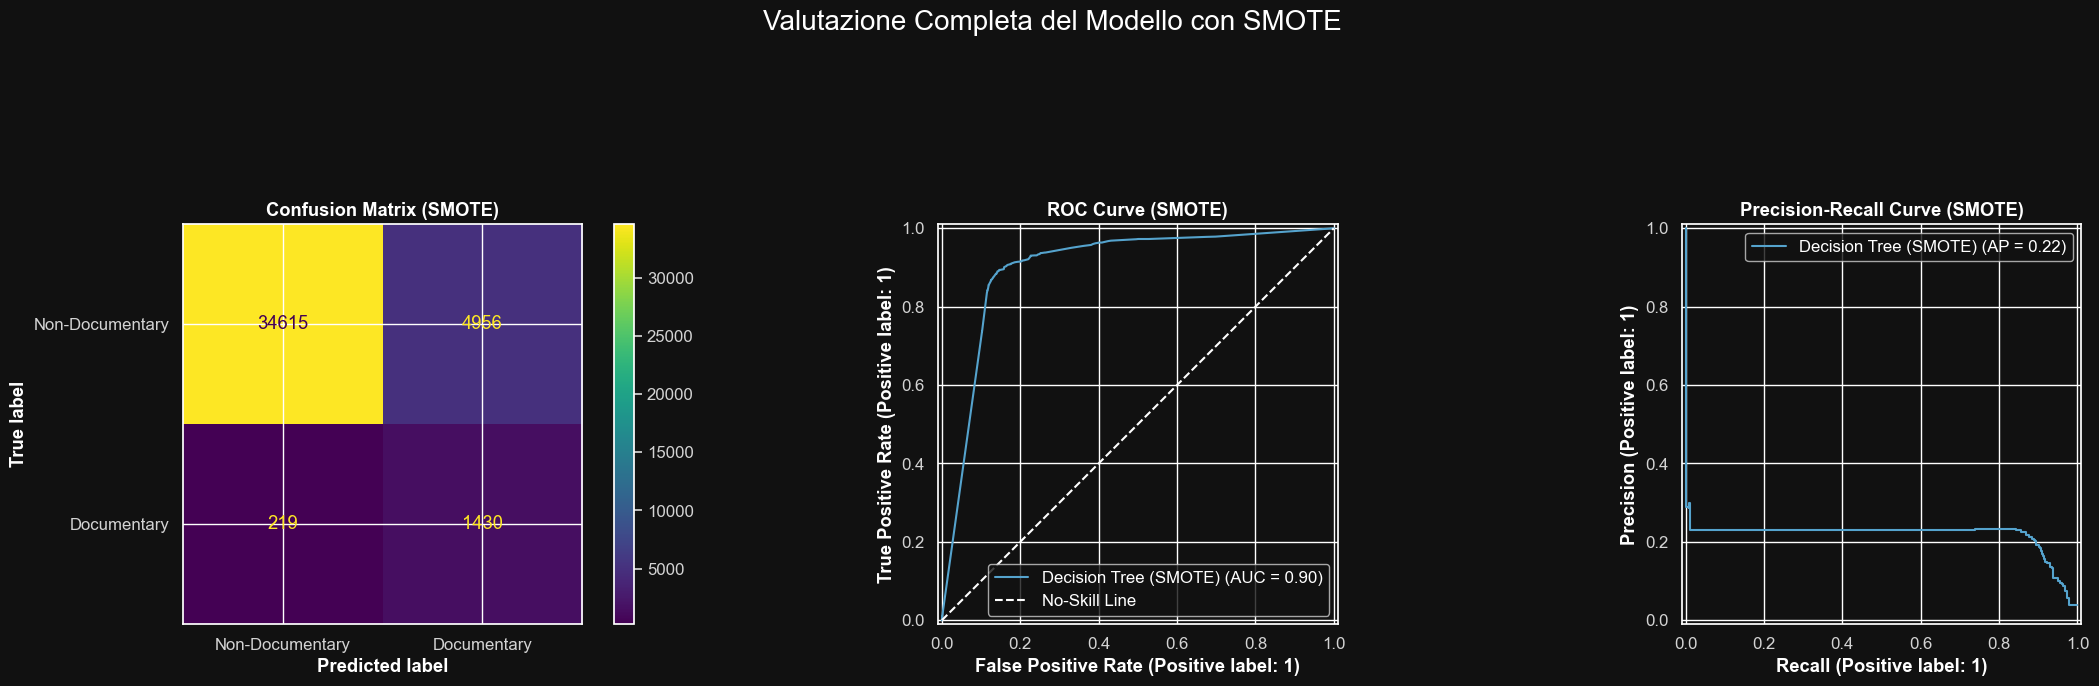


--- Analisi della Feature Importance (Modello SMOTE) ---
Le 20 feature più importanti secondo il modello SMOTE: ['writerCredits_proc', 'genres_comedy', 'genres_drama', 'genres_action', 'genres_animation', 'genres_reality-tv', 'genres_horror', 'startYear_proc', 'genres_thriller', 'genres_talk-show', 'genres_romance', 'genres_family', 'companiesNumber_proc', 'totalCredits_proc', 'numRegions_proc', 'genres_short', 'directorsCredits_proc', 'averageRating_proc', 'contentRichness_proc', 'regions_pt']


/var/folders/4l/s_d8z1kx7h762hwfcv4xhtsh0000gn/T/ipykernel_4829/2017495098.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_features_smote, y=top_20_features_smote.index, palette='viridis')


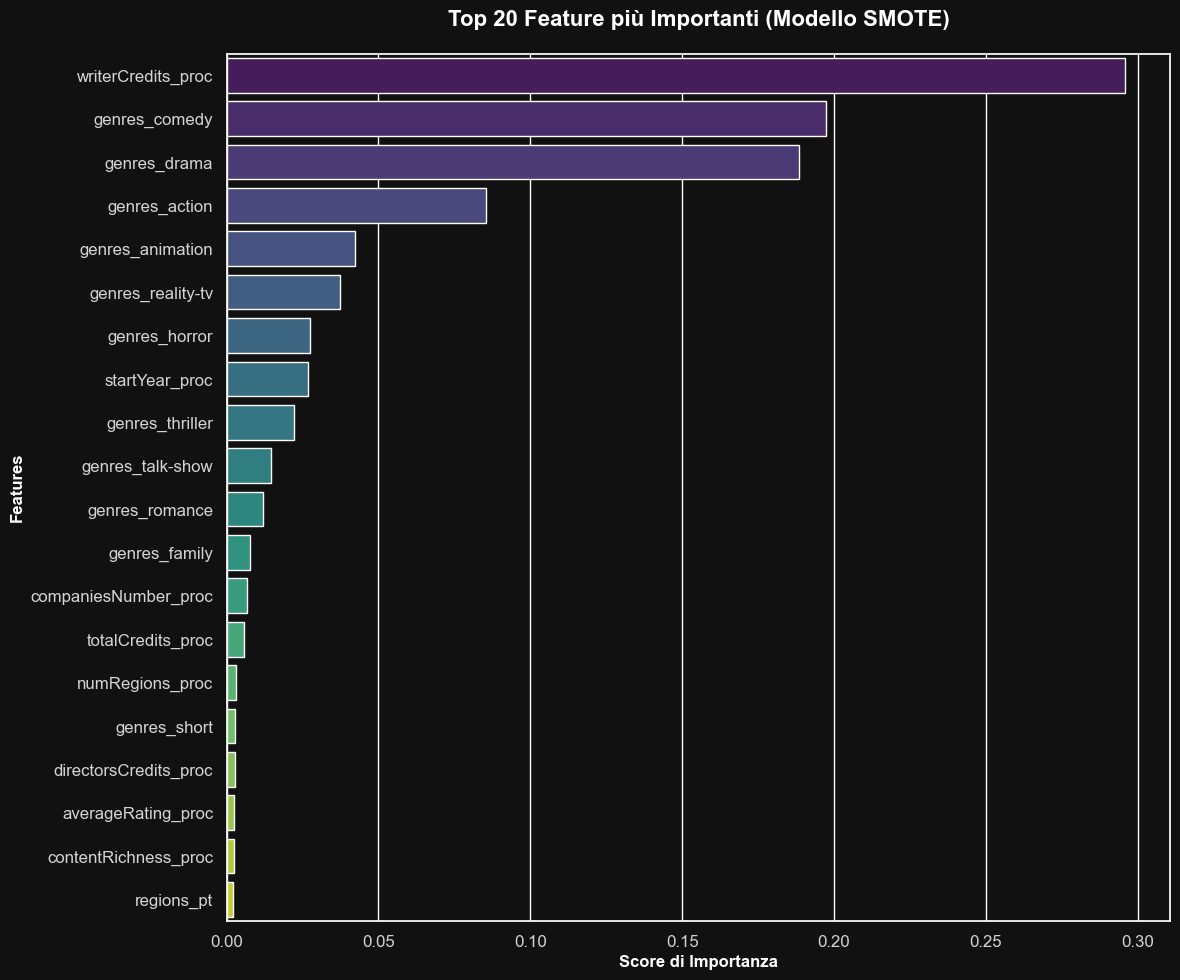

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

# --- PREREQUISITO: ASSICURARSI CHE LA LIBRERIA SIA INSTALLATA ---
# Se non l'ha già fatto, esegua questo comando nel suo terminale o in una cella del notebook:
# pip install -U imbalanced-learn

# --- 1. Applicazione di SMOTE al Solo Training Set ---
print("--- Applicazione di SMOTE al Training Set ---")
# Creiamo l'oggetto SMOTE. random_state garantisce la riproducibilità.
smote = SMOTE(random_state=42)

# Applichiamo il ricampionamento SOLO ai dati di addestramento (X_train, y_train)
# per evitare data leakage. Il test set non viene toccato.
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("✅ SMOTE applicato con successo.")
print("\n--- Verifica della Distribuzione Post-SMOTE ---")
print(f"Dimensioni del training set originale: X_train={X_train.shape}")
print(f"Dimensioni del training set con SMOTE: X_train_smote={X_train_smote.shape}")
print("\nDistribuzione delle classi nel nuovo training set bilanciato:")
# Contiamo i valori per verificare che le classi siano bilanciate
print(y_train_smote.value_counts())


# --- 2. Addestramento del Nuovo Decision Tree sui Dati Bilanciati ---
print("\n--- Addestramento del Decision Tree sui dati bilanciati con SMOTE ---")
# Usiamo gli stessi iperparametri del modello baseline per un confronto equo (max_depth=10)
smote_model = DecisionTreeClassifier(max_depth=10, random_state=42)
smote_model.fit(X_train_smote, y_train_smote)
print("✅ Modello SMOTE addestrato.")


# --- 3. Predizioni sul Test Set Originale (NON TOCCATO) ---
y_pred_smote = smote_model.predict(X_test)


# --- 4. Valutazione del Modello SMOTE ---
print("\n--- Performance del Modello SMOTE ---")
print("Classification Report:")
# Confrontiamo le predizioni (y_pred_smote) con i veri valori del test set (y_test)
print(classification_report(y_test, y_pred_smote, target_names=['Non-Documentary (0)', 'Documentary (1)']))


# --- 5. Visualizzazione delle Performance (come per la Baseline) ---
print("\nVisualizzazione delle metriche di performance per il modello SMOTE...")
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle("Valutazione Completa del Modello con SMOTE", fontsize=20, y=1.03)

# Subplot 1: Matrice di Confusione
ConfusionMatrixDisplay.from_estimator(
    smote_model, X_test, y_test,
    ax=axes[0], cmap='viridis', display_labels=['Non-Documentary', 'Documentary']
)
axes[0].set_title("Confusion Matrix (SMOTE)", fontweight='bold')

# Subplot 2: Curva ROC
RocCurveDisplay.from_estimator(
    smote_model, X_test, y_test, ax=axes[1], name='Decision Tree (SMOTE)'
)
axes[1].plot([0, 1], [0, 1], 'w--', label='No-Skill Line')
axes[1].set_title("ROC Curve (SMOTE)", fontweight='bold')
axes[1].legend()

# Subplot 3: Curva Precision-Recall
PrecisionRecallDisplay.from_estimator(
    smote_model, X_test, y_test, ax=axes[2], name='Decision Tree (SMOTE)'
)
axes[2].set_title("Precision-Recall Curve (SMOTE)", fontweight='bold')
axes[2].legend()

plt.tight_layout(pad=3.0, rect=[0, 0, 1, 0.95])
# Salviamo i grafici in un file con un nome specifico per SMOTE
plt.savefig(os.path.join(plots_dir, "evaluation_charts_smote.png"), dpi=300)
plt.show()


# --- 6. Analisi della Feature Importance per il Modello SMOTE ---
print("\n--- Analisi della Feature Importance (Modello SMOTE) ---")
feature_importances_smote = pd.Series(smote_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_20_features_smote = feature_importances_smote.head(20)

print(f"Le 20 feature più importanti secondo il modello SMOTE: {top_20_features_smote.index.tolist()}")

plt.figure(figsize=(12, 10))
sns.barplot(x=top_20_features_smote, y=top_20_features_smote.index, palette='viridis')
plt.title('Top 20 Feature più Importanti (Modello SMOTE)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Score di Importanza', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
# Salviamo il grafico in un file specifico
plt.savefig(os.path.join(plots_dir, "feature_importance_smote.png"), dpi=300)
plt.show()

### UNDERSAMPLING

--- Applicazione di RandomUnderSampler al Training Set ---
✅ RandomUnderSampler applicato con successo.

--- Verifica della Distribuzione Post-Undersampling ---
Dimensioni del training set originale: X_train=(96180, 85)
Dimensioni del training set con Undersampling: X_train_under=(7694, 85)

Distribuzione delle classi nel nuovo training set bilanciato:
isDocumentary
0    3847
1    3847
Name: count, dtype: int64

--- Addestramento del Decision Tree sui dati bilanciati con Undersampling ---
✅ Modello Undersampling addestrato.

--- Performance del Modello Undersampling ---
Classification Report:
                     precision    recall  f1-score   support

Non-Documentary (0)       0.99      0.83      0.91     39571
    Documentary (1)       0.18      0.88      0.30      1649

           accuracy                           0.83     41220
          macro avg       0.59      0.86      0.60     41220
       weighted avg       0.96      0.83      0.88     41220


Visualizzazione delle metriche

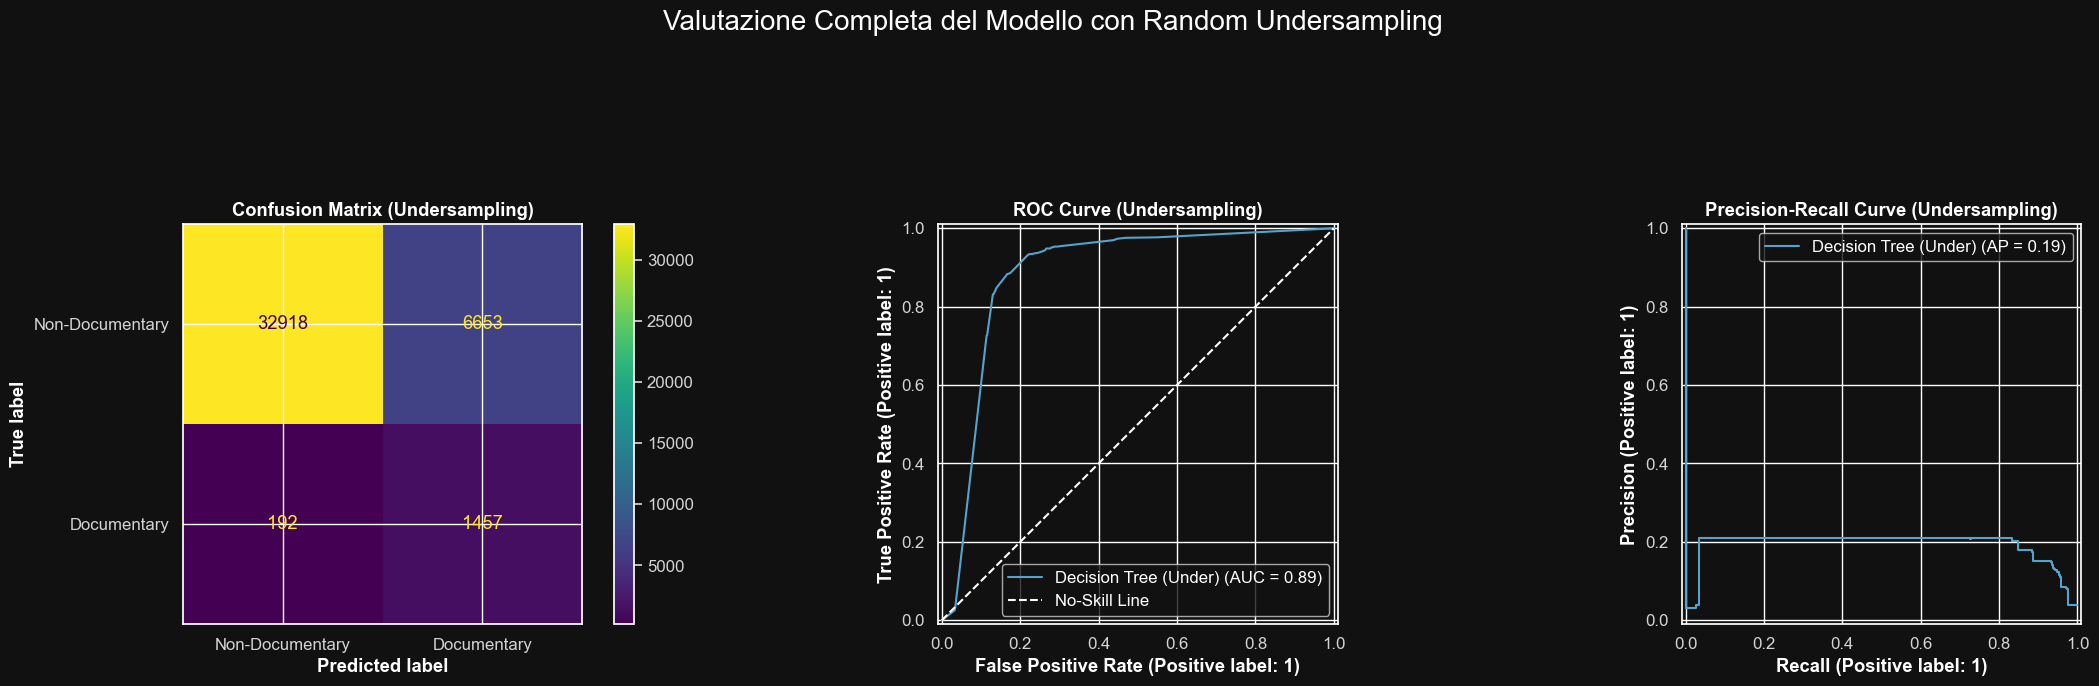


--- Analisi della Feature Importance (Modello Undersampling) ---
Le 20 feature più importanti secondo il modello Undersampling: ['genres_comedy', 'genres_drama', 'genres_action', 'genres_animation', 'startYear_proc', 'genres_thriller', 'totalCredits_proc', 'genres_romance', 'genres_reality-tv', 'genres_horror', 'runtimeMinutes_proc', 'averageRating_proc', 'genres_fantasy', 'companiesNumber_proc', 'hasWriterAndDirector', 'genres_short', 'type_tvSpecial', 'contentRichness_proc', 'genres_history', 'numVotes_proc']


/var/folders/4l/s_d8z1kx7h762hwfcv4xhtsh0000gn/T/ipykernel_4829/1851636641.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_features_under, y=top_20_features_under.index, palette='viridis')


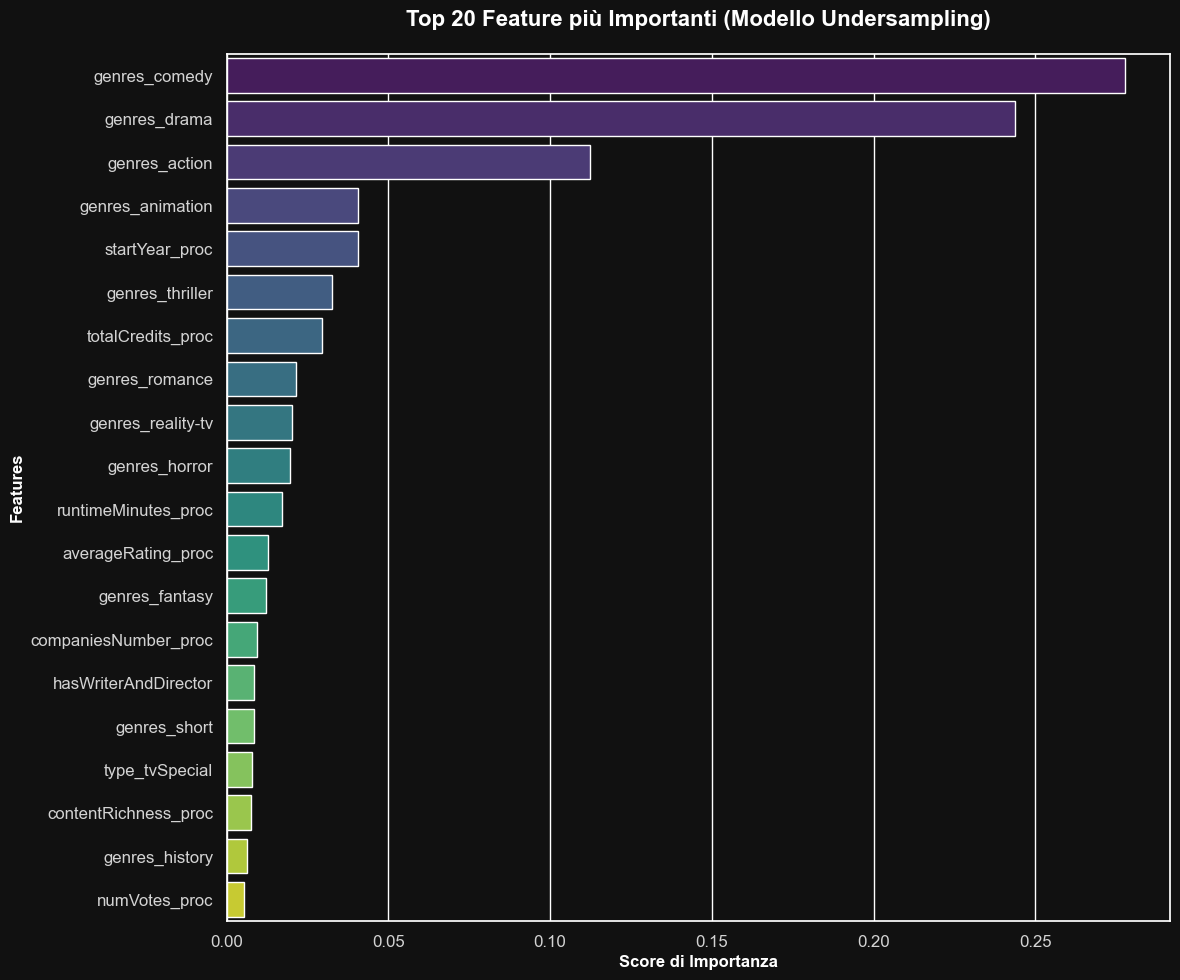

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from imblearn.under_sampling import RandomUnderSampler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

# --- PREREQUISITO: LA LIBRERIA imblearn DEVE ESSERE INSTALLATA ---

# --- 1. Applicazione di RandomUnderSampler al Solo Training Set ---
print("--- Applicazione di RandomUnderSampler al Training Set ---")
# Creiamo l'oggetto RandomUnderSampler.
rus = RandomUnderSampler(random_state=42)

# Applichiamo il ricampionamento SOLO ai dati di addestramento (X_train, y_train).
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("✅ RandomUnderSampler applicato con successo.")
print("\n--- Verifica della Distribuzione Post-Undersampling ---")
print(f"Dimensioni del training set originale: X_train={X_train.shape}")
print(f"Dimensioni del training set con Undersampling: X_train_under={X_train_under.shape}")
print("\nDistribuzione delle classi nel nuovo training set bilanciato:")
print(y_train_under.value_counts())


# --- 2. Addestramento del Decision Tree sui Dati Bilanciati ---
print("\n--- Addestramento del Decision Tree sui dati bilanciati con Undersampling ---")
# Usiamo gli stessi iperparametri per un confronto equo (max_depth=10)
under_model = DecisionTreeClassifier(max_depth=10, random_state=42)
under_model.fit(X_train_under, y_train_under)
print("✅ Modello Undersampling addestrato.")


# --- 3. Predizioni sul Test Set Originale (NON TOCCATO) ---
y_pred_under = under_model.predict(X_test)


# --- 4. Valutazione del Modello Undersampling ---
print("\n--- Performance del Modello Undersampling ---")
print("Classification Report:")
print(classification_report(y_test, y_pred_under, target_names=['Non-Documentary (0)', 'Documentary (1)']))


# --- 5. Visualizzazione delle Performance (come per i modelli precedenti) ---
print("\nVisualizzazione delle metriche di performance per il modello Undersampling...")
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle("Valutazione Completa del Modello con Random Undersampling", fontsize=20, y=1.03)

# Subplot 1: Matrice di Confusione
ConfusionMatrixDisplay.from_estimator(
    under_model, X_test, y_test,
    ax=axes[0], cmap='viridis', display_labels=['Non-Documentary', 'Documentary']
)
axes[0].set_title("Confusion Matrix (Undersampling)", fontweight='bold')

# Subplot 2: Curva ROC
RocCurveDisplay.from_estimator(
    under_model, X_test, y_test, ax=axes[1], name='Decision Tree (Under)'
)
axes[1].plot([0, 1], [0, 1], 'w--', label='No-Skill Line')
axes[1].set_title("ROC Curve (Undersampling)", fontweight='bold')
axes[1].legend()

# Subplot 3: Curva Precision-Recall
PrecisionRecallDisplay.from_estimator(
    under_model, X_test, y_test, ax=axes[2], name='Decision Tree (Under)'
)
axes[2].set_title("Precision-Recall Curve (Undersampling)", fontweight='bold')
axes[2].legend()

plt.tight_layout(pad=3.0, rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(plots_dir, "evaluation_charts_undersampling.png"), dpi=300)
plt.show()


# --- 6. Analisi della Feature Importance per il Modello Undersampling ---
print("\n--- Analisi della Feature Importance (Modello Undersampling) ---")
feature_importances_under = pd.Series(under_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_20_features_under = feature_importances_under.head(20)

print(f"Le 20 feature più importanti secondo il modello Undersampling: {top_20_features_under.index.tolist()}")

plt.figure(figsize=(12, 10))
sns.barplot(x=top_20_features_under, y=top_20_features_under.index, palette='viridis')
plt.title('Top 20 Feature più Importanti (Modello Undersampling)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Score di Importanza', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "feature_importance_undersampling.png"), dpi=300)
plt.show()